In [1]:
import pandas as pd
import sqlite3
import os

folder= r"C:\Users\TEWELDE\Documents\Medicare_project"

provider= pd.read_csv(os.path.join(folder, "Train-1542865627584.csv"))
bene       = pd.read_csv(os.path.join(folder, "Train_Beneficiarydata-1542865627584.csv"))
inpatient  = pd.read_csv(os.path.join(folder, "Train_Inpatientdata-1542865627584.csv"))
outpatient = pd.read_csv(os.path.join(folder, "Train_Outpatientdata-1542865627584.csv"))

print(len(provider), len(bene), len(inpatient), len(outpatient))

5410 138556 40474 517737


In [2]:
conn= sqlite3.connect("medicare.db")
provider.to_sql("provider", conn, if_exists="replace", index=False)
bene.to_sql("bene", conn, if_exists="replace", index=False)
inpatient.to_sql("Inpatient", conn, if_exists="replace", index=False)
outpatient.to_sql("Outpatient", conn, if_exists="replace", index=False)

517737

In [3]:
conn.executescript("""
DROP VIEW IF EXISTS AllClaims;
DROP VIEW IF EXISTS ProviderStats;

CREATE VIEW AllClaims AS
SELECT Provider, BeneID, ClaimID, InscClaimAmtReimbursed, 'Inpatient' AS ClaimType FROM Inpatient
UNION ALL
SELECT Provider, BeneID, ClaimID, InscClaimAmtReimbursed, 'Outpatient' AS ClaimType FROM Outpatient;

CREATE VIEW ProviderStats AS
SELECT Provider,
       COUNT(*) AS claim_count,
       COUNT(DISTINCT BeneID) AS unique_patients,
       AVG(InscClaimAmtReimbursed) AS avg_claim_amt,
       1.0*COUNT(*)/COUNT(DISTINCT BeneID) AS claims_per_patient
FROM AllClaims
GROUP BY Provider;
""")

def q(sql):
    return pd.read_sql_query(sql, conn)

In [4]:
q("""
SELECT p.PotentialFraud,
       COUNT(*) AS num_providers,
       ROUND(AVG(ps.claim_count), 1) AS avg_claims
FROM Provider p
JOIN ProviderStats ps ON p.Provider = ps.Provider
GROUP BY p.PotentialFraud
""")

,PotentialFraud,num_providers,avg_claims
0,No,4904,70.4
1,Yes,506,420.5


In [5]:
q("""
SELECT Provider,
       claim_count,
       ROUND(PERCENT_RANK() OVER (ORDER BY claim_count), 3) AS percentile
FROM ProviderStats
ORDER BY claim_count DESC
LIMIT 10
""")

,Provider,claim_count,percentile
0,PRV51459,8240,1.000
1,PRV53797,4739,1.000
2,PRV51574,4444,1.000
3,PRV53918,3588,0.999
4,PRV54895,3436,0.999
5,PRV55215,3393,0.999
6,PRV52064,2844,0.999
7,PRV56011,2833,0.999
8,PRV55004,2399,0.999
9,PRV57306,2315,0.998


In [6]:
q("""
SELECT MIN(claim_count) AS top10pct_cutoff
FROM (
    SELECT claim_count,
           NTILE(10) OVER (ORDER BY claim_count) AS decile
    FROM ProviderStats
)
WHERE decile = 10
""")

,top10pct_cutoff
0,228


In [7]:
q("""
SELECT Provider,
       claim_count,
       CASE WHEN claim_count >= 228 THEN 1 ELSE 0 END AS volume_point
FROM ProviderStats
ORDER BY claim_count DESC
LIMIT 10
""")

,Provider,claim_count,volume_point
0,PRV51459,8240,1
1,PRV53797,4739,1
2,PRV51574,4444,1
3,PRV53918,3588,1
4,PRV54895,3436,1
5,PRV55215,3393,1
6,PRV52064,2844,1
7,PRV56011,2833,1
8,PRV55004,2399,1
9,PRV57306,2315,1


In [8]:
q("""
SELECT p.PotentialFraud,
       COUNT(*) AS total_providers,
       SUM(CASE WHEN ps.claim_count >= 228 THEN 1 ELSE 0 END) AS above_cutoff,
       ROUND(100.0 * SUM(CASE WHEN ps.claim_count >= 228 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_above
FROM Provider p
JOIN ProviderStats ps ON p.Provider = ps.Provider
GROUP BY p.PotentialFraud
""")

,PotentialFraud,total_providers,above_cutoff,pct_above
0,No,4904,338,6.9
1,Yes,506,206,40.7


In [9]:
conn.executescript("""
DROP VIEW IF EXISTS ProviderSignals;

CREATE VIEW ProviderSignals AS
SELECT Provider,
       COUNT(*) AS claim_count,
       AVG(InscClaimAmtReimbursed) AS avg_claim_amt,
       1.0 * SUM(CASE WHEN ClaimType = 'Inpatient' THEN 1 ELSE 0 END) / COUNT(*) AS inpatient_share
FROM AllClaims
GROUP BY Provider;
""")

In [10]:
q("""
SELECT 'avg_claim_amt' AS signal,
       MIN(avg_claim_amt) AS top10pct_cutoff
FROM (SELECT avg_claim_amt, NTILE(10) OVER (ORDER BY avg_claim_amt) AS decile FROM ProviderSignals)
WHERE decile = 10
UNION ALL
SELECT 'inpatient_share',
       MIN(inpatient_share)
FROM (SELECT inpatient_share, NTILE(10) OVER (ORDER BY inpatient_share) AS decile FROM ProviderSignals)
WHERE decile = 10
""")

,signal,top10pct_cutoff
0,avg_claim_amt,5519.836066
1,inpatient_share,0.577465


In [11]:
q("""
SELECT p.PotentialFraud,
       COUNT(*) AS total_providers,
       ROUND(100.0 * SUM(CASE WHEN s.claim_count      >= 228     THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_high_volume,
       ROUND(100.0 * SUM(CASE WHEN s.avg_claim_amt    >= 5519.84 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_high_amount,
       ROUND(100.0 * SUM(CASE WHEN s.inpatient_share  >= 0.5775  THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_high_inpatient
FROM Provider p
JOIN ProviderSignals s ON p.Provider = s.Provider
GROUP BY p.PotentialFraud
""")

,PotentialFraud,total_providers,pct_high_volume,pct_high_amount,pct_high_inpatient
0,No,4904,6.9,8.3,8.7
1,Yes,506,40.7,26.5,22.3


In [12]:
conn.executescript("""
DROP VIEW IF EXISTS ProviderScore;

CREATE VIEW ProviderScore AS
WITH eligible AS (
    SELECT * FROM ProviderSignals WHERE claim_count >= 30
),
cutoffs AS (
    SELECT
      (SELECT MIN(claim_count)     FROM (SELECT claim_count,     NTILE(10) OVER (ORDER BY claim_count)     AS d FROM ProviderSignals) WHERE d = 10) AS vol_cut,
      (SELECT MIN(avg_claim_amt)   FROM (SELECT avg_claim_amt,   NTILE(10) OVER (ORDER BY avg_claim_amt)   AS d FROM eligible)        WHERE d = 10) AS amt_cut,
      (SELECT MIN(inpatient_share) FROM (SELECT inpatient_share, NTILE(10) OVER (ORDER BY inpatient_share) AS d FROM eligible)        WHERE d = 10) AS inp_cut
)
SELECT s.Provider, s.claim_count, s.avg_claim_amt, s.inpatient_share,
       CASE WHEN s.claim_count >= c.vol_cut THEN 1 ELSE 0 END AS volume_pt,
       CASE WHEN s.claim_count >= 30 AND s.avg_claim_amt   >= c.amt_cut THEN 1 ELSE 0 END AS amount_pt,
       CASE WHEN s.claim_count >= 30 AND s.inpatient_share >= c.inp_cut THEN 1 ELSE 0 END AS inpatient_pt,
       (CASE WHEN s.claim_count >= c.vol_cut THEN 1 ELSE 0 END)
     + (CASE WHEN s.claim_count >= 30 AND s.avg_claim_amt   >= c.amt_cut THEN 1 ELSE 0 END)
     + (CASE WHEN s.claim_count >= 30 AND s.inpatient_share >= c.inp_cut THEN 1 ELSE 0 END) AS risk_score
FROM ProviderSignals s CROSS JOIN cutoffs c;
""");

In [13]:
q("""
SELECT sc.risk_score,
       COUNT(*) AS providers,
       SUM(CASE WHEN p.PotentialFraud = 'Yes' THEN 1 ELSE 0 END) AS fraud_providers,
       ROUND(100.0 * SUM(CASE WHEN p.PotentialFraud = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_fraud
FROM ProviderScore sc
JOIN Provider p ON p.Provider = sc.Provider
GROUP BY sc.risk_score
ORDER BY sc.risk_score
""")

,risk_score,providers,fraud_providers,pct_fraud
0,0,4590,162,3.5
1,1,574,199,34.7
2,2,214,113,52.8
3,3,32,32,100.0


In [14]:
q("""
SELECT sc.Provider,
       sc.risk_score,
       sc.claim_count,
       ROUND(sc.avg_claim_amt, 0)         AS avg_claim_amt,
       ROUND(100 * sc.inpatient_share, 0) AS inpatient_pct,
       ROUND(t.total_reimbursed, 0)       AS total_reimbursed,
       TRIM(
         CASE WHEN sc.volume_pt    = 1 THEN 'High volume. ' ELSE '' END ||
         CASE WHEN sc.amount_pt    = 1 THEN 'High claim amount. ' ELSE '' END ||
         CASE WHEN sc.inpatient_pt = 1 THEN 'Inpatient-heavy.' ELSE '' END
       ) AS why_flagged,
       p.PotentialFraud AS actual_label
FROM ProviderScore sc
JOIN Provider p ON p.Provider = sc.Provider
JOIN (SELECT Provider, SUM(InscClaimAmtReimbursed) AS total_reimbursed
      FROM AllClaims
      GROUP BY Provider) t ON t.Provider = sc.Provider
WHERE sc.risk_score >= 2
ORDER BY sc.risk_score DESC, t.total_reimbursed DESC
LIMIT 10
""")

,Provider,risk_score,claim_count,avg_claim_amt,inpatient_pct,total_reimbursed,why_flagged,actual_label
0,PRV54367,3,636,4927.0,51.0,3133880.0,High volume. High claim amount. Inpatient-heavy.,Yes
1,PRV55209,3,762,3825.0,36.0,2914700.0,High volume. High claim amount. Inpatient-heavy.,Yes
2,PRV53706,3,473,5987.0,60.0,2831940.0,High volume. High claim amount. Inpatient-heavy.,Yes
3,PRV55230,3,565,4624.0,40.0,2612740.0,High volume. High claim amount. Inpatient-heavy.,Yes
4,PRV54955,3,314,6799.0,65.0,2134890.0,High volume. High claim amount. Inpatient-heavy.,Yes
5,PRV52846,3,241,8784.0,73.0,2117010.0,High volume. High claim amount. Inpatient-heavy.,Yes
6,PRV51501,3,233,8890.0,96.0,2071310.0,High volume. High claim amount. Inpatient-heavy.,Yes
7,PRV54765,3,239,8370.0,82.0,2000500.0,High volume. High claim amount. Inpatient-heavy.,Yes
8,PRV51940,3,251,7937.0,77.0,1992270.0,High volume. High claim amount. Inpatient-heavy.,Yes
9,PRV51560,3,238,8219.0,84.0,1956190.0,High volume. High claim amount. Inpatient-heavy.,Yes


In [15]:
q("""
SELECT COUNT(*) AS shortlist_size,
       SUM(CASE WHEN p.PotentialFraud = 'Yes' THEN 1 ELSE 0 END) AS fraud_in_shortlist,
       ROUND(SUM(t.total_reimbursed) / 1e6, 1) AS shortlist_reimbursed_millions
FROM ProviderScore sc
JOIN Provider p ON p.Provider = sc.Provider
JOIN (SELECT Provider, SUM(InscClaimAmtReimbursed) AS total_reimbursed
      FROM AllClaims
      GROUP BY Provider) t ON t.Provider = sc.Provider
WHERE sc.risk_score >= 2
""")

,shortlist_size,fraud_in_shortlist,shortlist_reimbursed_millions
0,246,145,168.1


In [16]:
df = q("""
SELECT sc.Provider,
       p.PotentialFraud                   AS fraud_label,
       sc.risk_score,
       CASE sc.risk_score WHEN 0 THEN 'Low' WHEN 1 THEN 'Medium' WHEN 2 THEN 'High' ELSE 'Critical' END AS risk_tier,
       sc.claim_count,
       ROUND(sc.avg_claim_amt, 2)         AS avg_claim_amt,
       ROUND(100 * sc.inpatient_share, 1) AS inpatient_pct,
       ROUND(t.total_reimbursed, 2)       AS total_reimbursed,
       sc.volume_pt, sc.amount_pt, sc.inpatient_pt,
       TRIM(
         CASE WHEN sc.volume_pt    = 1 THEN 'High volume. ' ELSE '' END ||
         CASE WHEN sc.amount_pt    = 1 THEN 'High claim amount. ' ELSE '' END ||
         CASE WHEN sc.inpatient_pt = 1 THEN 'Inpatient-heavy.' ELSE '' END
       ) AS why_flagged
FROM ProviderScore sc
JOIN Provider p ON p.Provider = sc.Provider
JOIN (SELECT Provider, SUM(InscClaimAmtReimbursed) AS total_reimbursed
      FROM AllClaims GROUP BY Provider) t ON t.Provider = sc.Provider
ORDER BY sc.risk_score DESC, t.total_reimbursed DESC
""")

df.to_csv(os.path.join(folder, "provider_scorecard.csv"), index=False)
print(df.shape)
df.head(3)

(5410, 12)


,Provider,fraud_label,risk_score,risk_tier,claim_count,avg_claim_amt,inpatient_pct,total_reimbursed,volume_pt,amount_pt,inpatient_pt,why_flagged
0,PRV54367,Yes,3,Critical,636,4927.48,50.6,3133880.0,1,1,1,High volume. High claim amount. Inpatient-heavy.
1,PRV55209,Yes,3,Critical,762,3825.07,36.1,2914700.0,1,1,1,High volume. High claim amount. Inpatient-heavy.
2,PRV53706,Yes,3,Critical,473,5987.19,59.6,2831940.0,1,1,1,High volume. High claim amount. Inpatient-heavy.


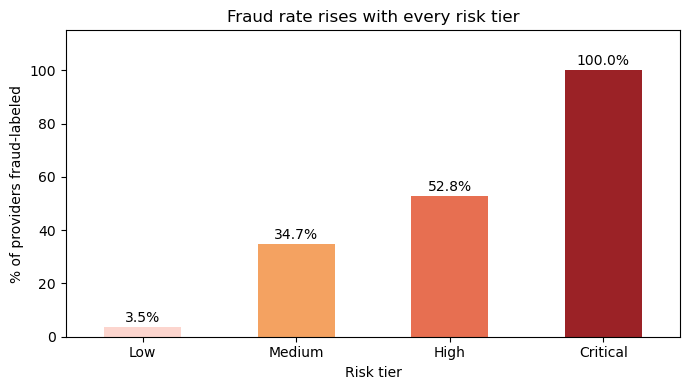

In [17]:
import matplotlib.pyplot as plt

order = ["Low", "Medium", "High", "Critical"]

rate = (df.assign(is_fraud = df.fraud_label.eq("Yes"))
          .groupby("risk_tier")["is_fraud"].mean()
          .reindex(order) * 100)

colors = ["#fcd5ce", "#f4a261", "#e76f51", "#9b2226"]

ax = rate.plot(kind="bar", color=colors, figsize=(7, 4), rot=0)
ax.set_title("Fraud rate rises with every risk tier")
ax.set_xlabel("Risk tier")
ax.set_ylabel("% of providers fraud-labeled")
ax.set_ylim(0, 115)

for i, v in enumerate(rate):
    ax.text(i, v + 2, f"{v:.1f}%", ha="center")

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/fraud_rate_by_tier.png", dpi=150, bbox_inches="tight")
plt.show()
plt.show()

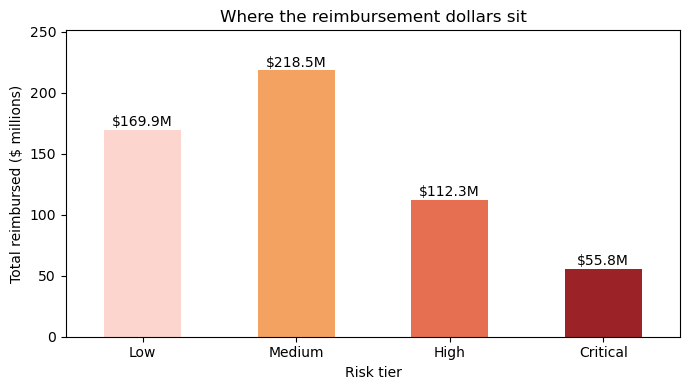

In [18]:
order  = ["Low", "Medium", "High", "Critical"]
colors = ["#fcd5ce", "#f4a261", "#e76f51", "#9b2226"]

dollars = df.groupby("risk_tier")["total_reimbursed"].sum().reindex(order) / 1e6

ax = dollars.plot(kind="bar", color=colors, figsize=(7, 4), rot=0)
ax.set_title("Where the reimbursement dollars sit")
ax.set_xlabel("Risk tier")
ax.set_ylabel("Total reimbursed ($ millions)")
ax.set_ylim(0, dollars.max() * 1.15)

for i, v in enumerate(dollars):
    ax.text(i, v + 3, f"${v:.1f}M", ha="center")

plt.tight_layout()
plt.savefig("images/dollars_by_tier.png", dpi=150, bbox_inches="tight")
plt.show()

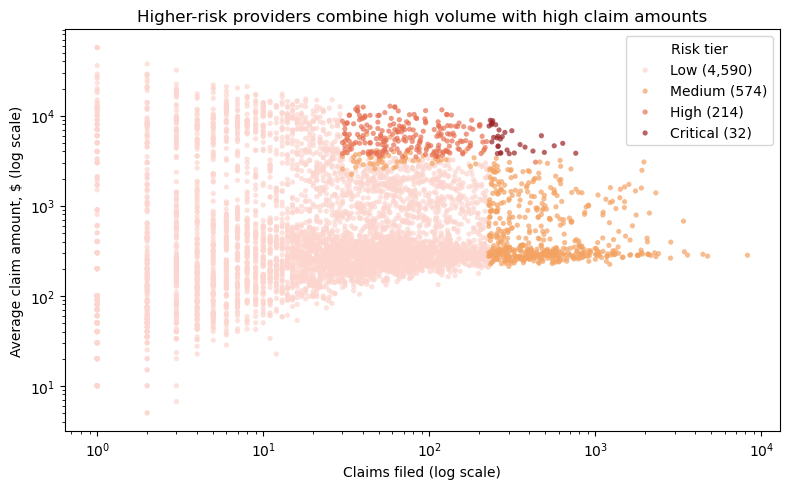

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

for tier, col in zip(order, colors):
    sub = df[df.risk_tier == tier]
    ax.scatter(sub.claim_count, sub.avg_claim_amt,
               s=14, alpha=0.7, color=col,
               label=f"{tier} ({len(sub):,})", edgecolors="none")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Claims filed (log scale)")
ax.set_ylabel("Average claim amount, $ (log scale)")
ax.set_title("Higher-risk providers combine high volume with high claim amounts")
ax.legend(title="Risk tier")

plt.tight_layout()
plt.savefig("images/risk_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
shortlist = (df[df.risk_score >= 2]
             .sort_values(["risk_score", "total_reimbursed"], ascending=False)
             [["Provider", "risk_tier", "claim_count", "avg_claim_amt",
               "inpatient_pct", "total_reimbursed", "why_flagged"]]
             .reset_index(drop=True))

shortlist.index += 1     # number the rows from 1 instead of 0

print(shortlist.shape)
shortlist.head(15)
os.makedirs("outputs", exist_ok=True)
shortlist.to_csv("outputs/audit_shortlist.csv", index=True, index_label="rank")
df.to_csv("outputs/provider_scorecard.csv", index=False)

(246, 7)


In [21]:
flagged     = df[df.risk_score >= 2]
total_fraud = df.fraud_label.eq("Yes").sum()
caught      = flagged.fraud_label.eq("Yes").sum()

precision = caught / len(flagged)
recall    = caught / total_fraud
base_rate = total_fraud / len(df)
lift      = precision / base_rate
dollar_share = flagged.total_reimbursed.sum() / df.total_reimbursed.sum()

print(f"Providers on shortlist:        {len(flagged)}")
print(f"Fraud-labeled among them:      {caught}")
print(f"Precision (shortlist hit rate): {precision:.1%}")
print(f"Recall (fraud caught):          {recall:.1%}")
print(f"Base rate (all providers):      {base_rate:.1%}")
print(f"Lift vs. random:                {lift:.1f}x")
print(f"Share of reimbursement dollars: {dollar_share:.1%}")

Providers on shortlist:        246
Fraud-labeled among them:      145
Precision (shortlist hit rate): 58.9%
Recall (fraud caught):          28.7%
Base rate (all providers):      9.4%
Lift vs. random:                6.3x
Share of reimbursement dollars: 30.2%


In [22]:
import os
os.makedirs("images", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
print(os.listdir("images"))
print(os.listdir("outputs"))

['dollars_by_tier.png', 'fraud_rate_by_tier.png', 'risk_scatter.png']
['audit_shortlist.csv', 'provider_scorecard.csv']


## Summary

Healthcare fraud costs Medicare and Medicaid billions of dollars a year, and compliance teams can't manually review every provider. This project tests whether billing data alone can point auditors to the providers most worth reviewing first.

**Data:** 5,410 providers, 558,211 claims, about $557M in reimbursements. 506 providers (9.4%) are labeled as potentially fraudulent.

**What separates flagged providers from the rest:**
- They file about 6x more claims (420 vs. 70 on average).
- They bill about 2.5x more per claim ($3,843 vs. $1,524).
- They're about 2x as likely to bill for hospital stays (11% of claims vs. 4.9%).

Two ideas did *not* hold up: patients' chronic-condition counts were identical (4.32 vs. 4.32), and "billing the same patient repeatedly" showed almost no difference (1.48 vs. 1.31). Both were left out of the final score.

**The risk score:** one point each for high volume, high claim amount, and high inpatient share (each the top 10% of providers), for a score of 0–3. Providers with fewer than 30 claims can't earn the amount or inpatient points, since their averages are based on too little data to be reliable.

**Results:** the share of flagged providers rises with every point — 3.5% (Low) → 34.7% (Medium) → 52.8% (High) → 100% (Critical).

**Recommendation:** review the 246 providers scoring 2 or higher first.
- 4.5% of all providers, but $168M (30%) of all reimbursement dollars
- 59% of them are labeled potentially fraudulent, vs. 9.4% overall — a 6.3x lift over random selection

## Limitations

- **A prioritization tool, not proof of fraud.** Every flagged provider still needs human review.
- **Low recall.** The shortlist catches only 29% of labeled providers (145 of 506). Many don't stand out on these three measures.
- **The label means "potentially fraudulent,"** not confirmed fraud.
- **Tuned and tested on the same data.** The 30-claim minimum was chosen after seeing a flawed first result. A real deployment should validate rules on separate, unseen data.
- **One snapshot in time.** Billing patterns and fraud tactics change.